In [ ]:
import psycopg2
import pandas as pd

conn = psycopg2.connect(
    host="localhost",
    database="olist",
    user="YOUR_USERNAME",
    password="YOUR_PASSWORD",
    port="5432"
)

print("Successfully connected to the database!")


df = pd.read_sql("SELECT * FROM olist_orders_dataset LIMIT 10", conn)
print(df)

Successfully connected to the database!
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   
5  a4591c265e18cb1dcee52889e2d8acc3  503740e9ca751ccdda7ba28e9ab8f608   
6  136cce7faa42fdb2cefd53fdc79a6098  ed0271e0b7da060a393796590e7b737a   
7  6514b8ad8028c9f2cc2374ded245783f  9bdf08b4b3b52b5526ff42d37d47f222   
8  76c6e866289321a7c93b82b54852dc33  f54a9f0e6b351c431402b8461ea51999   
9  e69bfb5eb88e0ed6a785585b27e16dbf  31ad1d1b63eb9962463f764d4e6e0c9d   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-

/var/folders/r3/2lzj6qp93wdb8dqtwtw036fw0000gn/T/ipykernel_6104/2934457979.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM olist_orders_dataset LIMIT 10", conn)


In [3]:
query = """
SELECT 
    ood.customer_id,
    CURRENT_DATE - MAX(ood.order_purchase_timestamp::timestamp)::date AS recency,
    COUNT(DISTINCT ood.order_id) AS frequency,
    SUM(ooid.price) AS monetary
FROM olist_orders_dataset ood
JOIN olist_order_items_dataset ooid ON ooid.order_id = ood.order_id
GROUP BY ood.customer_id
"""

df_rfm = pd.read_sql(query, conn)
print(df_rfm.head())

/var/folders/r3/2lzj6qp93wdb8dqtwtw036fw0000gn/T/ipykernel_6104/2777515606.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_rfm = pd.read_sql(query, conn)


                        customer_id  recency  frequency  monetary
0  00012a2ce6f8dcda20d059ce98491703     3147          1     89.80
1  000161a058600d5901f007fab4c27140     3268          1     54.90
2  0001fd6190edaaf884bcaf3d49edf079     3406          1    179.99
3  0002414f95344307404f0ace7a26f1d5     3237          1    149.90
4  000379cdec625522490c315e70c7a9fb     3008          1     93.00


In [4]:
def segment(row):
    r = row['recency_score']
    f = row['frequency_score']
    if r == 5 and f == 5:
        return 'Champions'
    elif r >= 4 and f >= 3:
        return 'Loyal'
    elif r == 5 and f <= 2:
        return 'New Customer'
    elif r <= 2 and f >= 4:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost'
    else:
        return 'Potential'

df_rfm['recency_score'] = pd.qcut(df_rfm['recency'], 5, labels=[5,4,3,2,1])
df_rfm['frequency_score'] = pd.qcut(df_rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
df_rfm['monetary_score'] = pd.qcut(df_rfm['monetary'].rank(method='first'), 5, labels=[1,2,3,4,5])
df_rfm['segment'] = df_rfm.apply(segment, axis=1)

df_rfm.head(10)

,customer_id,recency,frequency,monetary,recency_score,frequency_score,monetary_score,segment
0,00012a2ce6f8dcda20d059ce98491703,3147,1,89.80,2,1,3,Lost
1,000161a058600d5901f007fab4c27140,3268,1,54.90,1,1,2,Lost
2,0001fd6190edaaf884bcaf3d49edf079,3406,1,179.99,1,1,5,Lost
3,0002414f95344307404f0ace7a26f1d5,3237,1,149.90,2,1,4,Lost
4,000379cdec625522490c315e70c7a9fb,3008,1,93.00,4,1,3,Potential
5,0004164d20a9e969af783496f3408652,3363,1,59.99,1,1,2,Lost
6,000419c5494106c306a97b5635748086,3039,1,34.30,4,1,1,Potential
7,00046a560d407e99b969756e0b10f282,3113,1,120.90,3,1,4,Potential
8,00050bf6e01e69d5c0fd612f1bcfb69c,3205,1,69.99,2,1,3,Lost
9,000598caf2ef4117407665ac33275130,2877,1,1107.00,5,1,5,New Customer


In [5]:
df_rfm['segment'].value_counts()

segment
Potential       35713
Loyal           19716
At Risk         15763
Lost            15592
New Customer     7941
Champions        3941
Name: count, dtype: int64

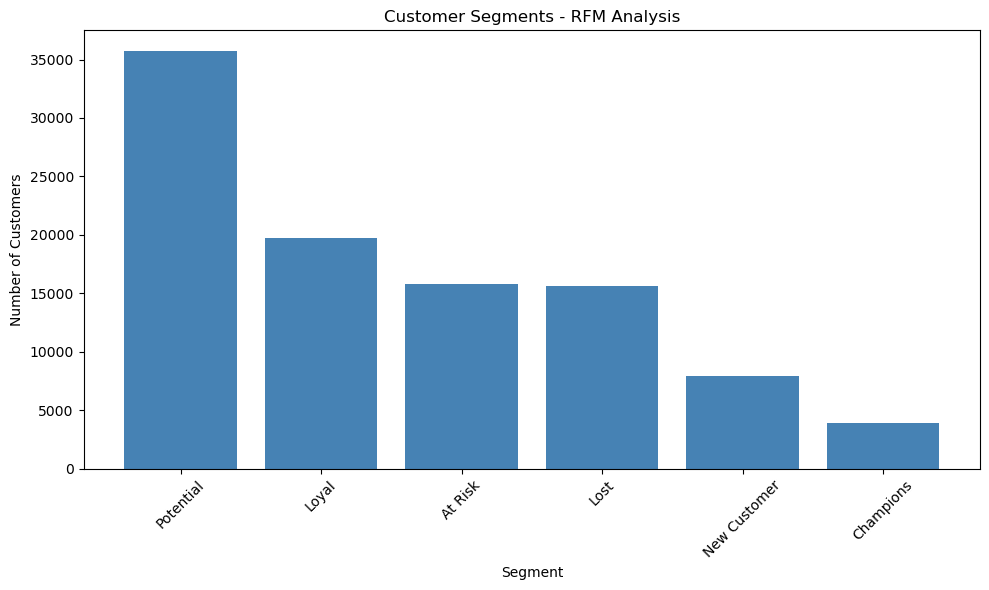

In [6]:
import matplotlib.pyplot as plt

segment_counts = df_rfm['segment'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(segment_counts.index, segment_counts.values, color='steelblue')
plt.title('Customer Segments - RFM Analysis')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()